In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
import os

os.getcwd()

'/content'

In [63]:
import pandas as pd

df = pd.read_csv("/content/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [64]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [65]:
df.shape

(768, 7)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [67]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [68]:
df['Area'].unique()

array(['Rural', nan, 'Urban'], dtype=object)

In [69]:
df['Area'].value_counts()

,count
Area,
Urban,381
Rural,359


In [70]:
df['Area'].isnull().value_counts()

,count
Area,
False,740
True,28


In [71]:
df['Frequency'].unique()

array([' Monthly', nan, 'Monthly'], dtype=object)

In [72]:
df['Frequency'].value_counts()

,count
Frequency,
Monthly,381
Monthly,359


In [73]:
df['Date'].head()

,Date
0,31-05-2019
1,30-06-2019
2,31-07-2019
3,31-08-2019
4,30-09-2019


In [74]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_577/936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [75]:
df['Date'].head()

,Date
0,2019-05-31
1,2019-06-30
2,2019-07-31
3,2019-08-31
4,2019-09-30


In [76]:
df["Date"].dtype

dtype('<M8[ns]')

In [77]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [78]:
df[df.isnull().any(axis=1)].head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [79]:
df = df.dropna(how="all")

In [80]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [83]:
df["Frequency"] = df["Frequency"].str.strip()

In [84]:
print("Regions:", df["Region"].nunique())
print(df["Region"].unique())

print("\nFrequency:")
print(df["Frequency"].value_counts())

print("\nArea:")
print(df["Area"].value_counts())

Regions: 28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Frequency:
Frequency
Monthly    740
Name: count, dtype: int64

Area:
Area
Urban    381
Rural    359
Name: count, dtype: int64


In [85]:
monthly_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

monthly_unemployment

,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731
2019-10-31,9.900909
2019-11-30,9.868364
2019-12-31,9.497358
2020-01-31,9.950755


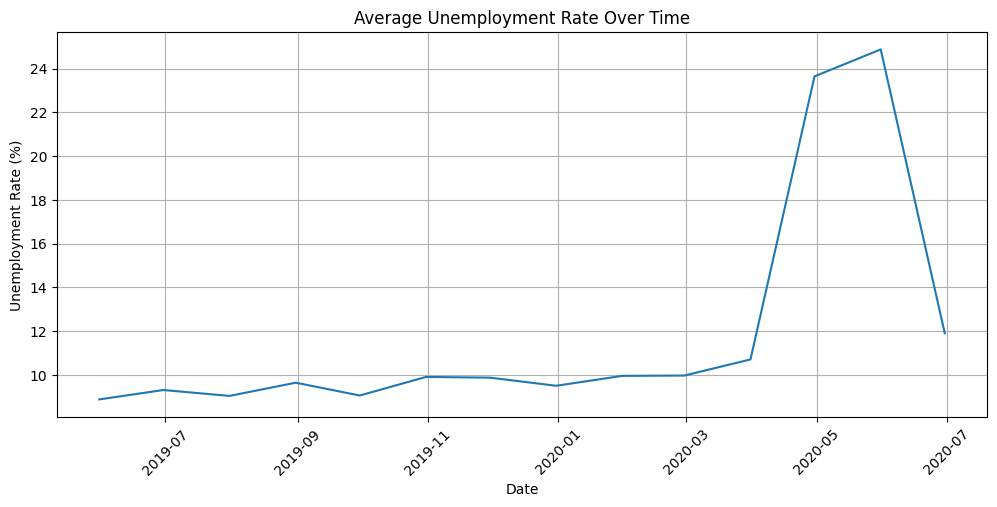

In [86]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_unemployment.index, monthly_unemployment.values)

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Overall Trend

- From May 2019 to February 2020, unemployment stayed roughly around 9–10%.
- In March 2020, it increased to about 10.7%.
- In April 2020, it jumped dramatically to 23.64%.
- In May 2020, it reached the highest value in this dataset: 24.88%.
- By June 2020, it dropped to about 11.90%, showing a substantial decrease from the April–May peak, though it remained above most of the 2019 values.

In [87]:
region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_unemployment

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


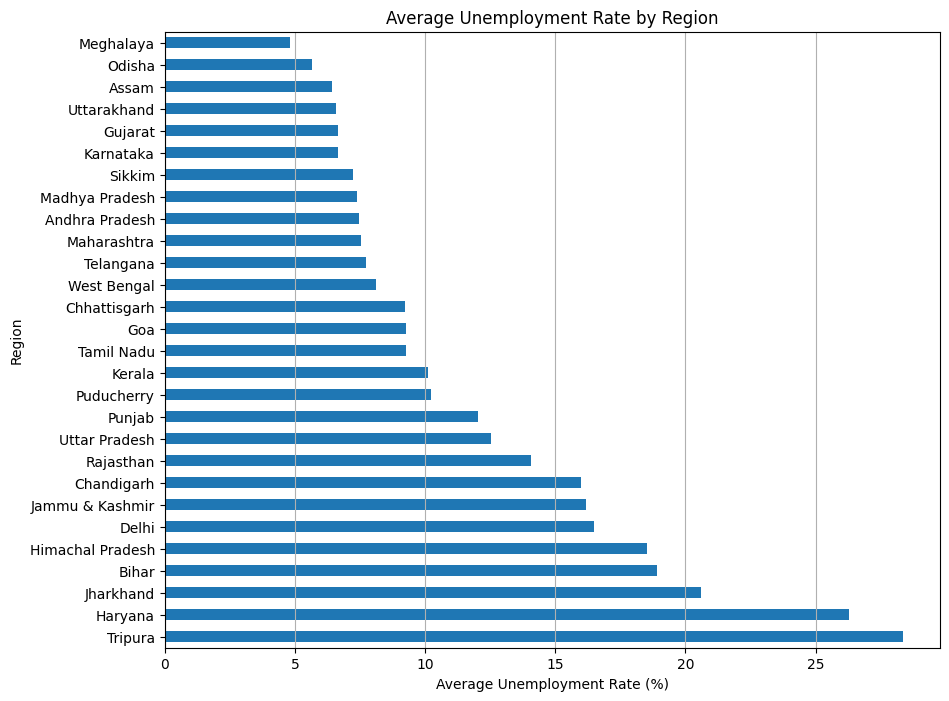

In [88]:
plt.figure(figsize=(10, 8))

region_unemployment.plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.grid(axis="x")

plt.show()

### Regional Analysis

- **Tripura** has the highest average unemployment rate in this dataset, at about **28.35%**.
- **Haryana** follows at about **26.28%**.
- **Jharkhand, Bihar, and Himachal Pradesh** also have relatively high average rates.
- **Meghalaya** has the lowest average in this dataset, at about **4.80%**.
- **Odisha, Assam, Uttarakhand, Gujarat, and Karnataka** are also among the regions with lower average unemployment rates.
- There is a substantial difference between regions, showing that unemployment was **not distributed uniformly across the regions** in the dataset.

In [89]:
area_unemployment = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
      .mean()
)

area_unemployment

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


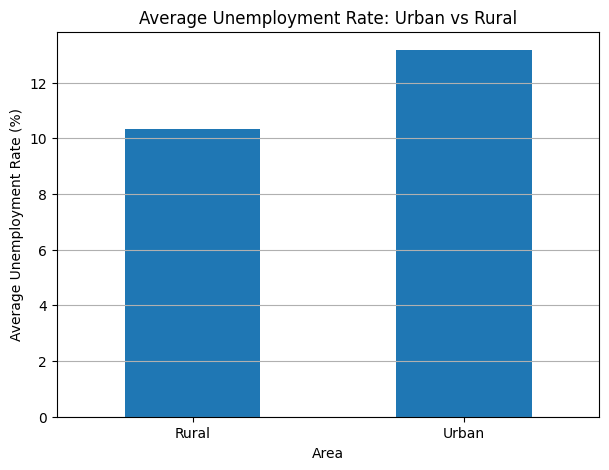

In [90]:
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

### Rural Vs Urban

- **Rural average:** 10.32%
- **Urban average:** 13.17%
- The Urban average is about **2.84 percentage points higher** than the Rural average.

So, within this dataset and time period, **urban areas had a higher average unemployment rate than rural areas**.

In [91]:
df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].mean()

,0
Estimated Unemployment Rate (%),1.178795e+01
Estimated Employed,7.204460e+06
Estimated Labour Participation Rate (%),4.263012e+01


- **Unemployment Rate:** 11.79 %
- **Estimated Employed:** 7.20 million
- **Labour Participation Rate:** 42.63%

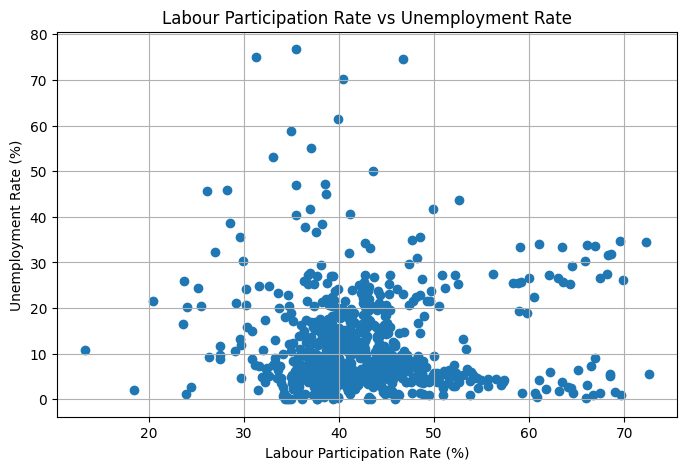

In [92]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Estimated Labour Participation Rate (%)"],
    df["Estimated Unemployment Rate (%)"]
)

plt.title("Labour Participation Rate vs Unemployment Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

In [93]:
df["Date"].min(), df["Date"].max()

(Timestamp('2019-05-31 00:00:00'), Timestamp('2020-06-30 00:00:00'))

In [94]:
pre_covid = df[df["Date"] < "2020-03-01"]

covid_period = df[df["Date"] >= "2020-03-01"]

print("Pre-COVID average unemployment rate:",
      pre_covid["Estimated Unemployment Rate (%)"].mean())

print("COVID-period average unemployment rate:",
      covid_period["Estimated Unemployment Rate (%)"].mean())

Pre-COVID average unemployment rate: 9.509533582089553
COVID-period average unemployment rate: 17.774362745098042


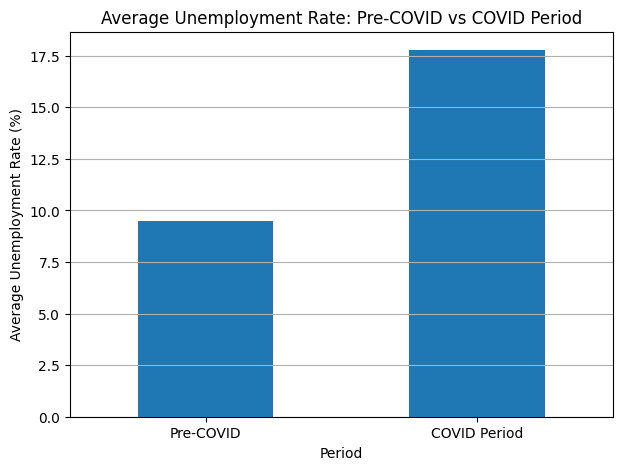

In [95]:
covid_comparison = pd.Series({
    "Pre-COVID": pre_covid["Estimated Unemployment Rate (%)"].mean(),
    "COVID Period": covid_period["Estimated Unemployment Rate (%)"].mean()
})

plt.figure(figsize=(7, 5))

covid_comparison.plot(kind="bar")

plt.title("Average Unemployment Rate: Pre-COVID vs COVID Period")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

### COVID-19 Impact

Unemployment increased substantially during the COVID-affected period compared with the pre-COVID period in this dataset.

Here we can divide the period into:

**Pre-COVID:** *May 2019 – February 2020*
**COVID-affected period:** *March 2020 – June 2020*
- **Pre-COVID average:** 9.51%
- **COVID-period average:** 17.77%
- **Increase:** 8.26 percentage points
- That's roughly an 87% increase relative to the pre-COVID average.
- The monthly data shows that the biggest spike occurred in April (23.64%) and May 2020 (24.88%).
- By June 2020, unemployment fell to 11.90%, showing a substantial decline from the April–May peak.

In [96]:
df["Month"] = df["Date"].dt.month_name()

In [97]:
df["Month_Number"] = df["Date"].dt.month

In [98]:
monthly_pattern = (
    df.groupby("Month_Number")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_index()
)

monthly_pattern

,Estimated Unemployment Rate (%)
Month_Number,
1,9.950755
2,9.964717
3,10.700577
4,23.641569
5,16.646190
6,10.553462
7,9.033889
8,9.637925
9,9.051731


### Monthly Pattern Analysis

Unemployment remained relatively stable across most months, generally around 6–10%, but increased sharply during April and May 2020, coinciding with the COVID-affected period. The data therefore shows a major temporary disruption rather than enough evidence to establish a recurring seasonal pattern.

### Conclusion

This analysis examined unemployment trends across different regions and areas in India using Python. The results show substantial regional variation and a clear increase in unemployment during the COVID-19-affected period.

The average unemployment rate rose from approximately 9.51% before March 2020 to 17.77% during March–June 2020, with the sharpest increase occurring in April and May 2020. Urban areas also recorded a higher average unemployment rate than rural areas during the dataset period.

Overall, the analysis demonstrates how data cleaning, exploratory analysis, grouping, and visualization can be used to identify important patterns in employment data. These findings can help highlight areas and periods that may require closer economic and social analysis. However, the dataset covers only May 2019 to June 2020, so longer-term trends and recurring seasonal patterns cannot be established from this dataset alone.